#### En esta etapa analizamos los logs generados en el paso anterior para validar si separar el tipo de producto tiene alguna incidencia en el rendimiento de los modelos
#### se probaron:
    - Regresion Logistica
    - Naive Bayes
    - KNeighbors
    - LinearSVC
    - SGDClassifier
    y como adicional
    - CatBoost
#### Adicionalmente en el analisis de PCA se puede observar que de las 18 componentes, se necesitan al menos 14 de ellas para llegar a un 90% de explicación de la varianza, y que por lo tanto no tenemos un gran beneficio por reducir variables. En las pruebas usar PCA demostró tener un resultado levemente negativo

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import offsetbox

from sklearn.pipeline import Pipeline,make_pipeline, make_union
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score,make_scorer,precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
import catboost as cat
from catboost import CatBoostClassifier, Pool
import shap

%matplotlib inline

#### Lectura de los resultados de los modelos, El primero tiene todos los resultados, luego hay un file por cada tipo de producto

In [64]:
df   = pd.read_csv('../Datos/resultados_All_types.csv') #resultados de entrenamiento de modelos con todos los tipos de polizas
dfp2 = pd.read_csv('../Datos/resultados_plan_2.csv')
dfp3 = pd.read_csv('../Datos/resultados_plan_3.csv')
dfp4 = pd.read_csv('../Datos/resultados_plan_4.csv')
dfp5 = pd.read_csv('../Datos/resultados_plan_5.csv')
metricas = pd.read_csv('../Datos/metrics.csv') ### Contiene las metricas de train y test de los mejores modelos de cada corrida

Columns (16,18) have mixed types.Specify dtype option on import or set low_memory=False.


In [65]:
df.shape

(26298, 41)

In [66]:
### La seleccion de modelos incluyo 26298 testeos con 5 folds cada uno

##### vamos a filtrar y quedarnos con los 5 mejores del df general por ranking de F1 y compararlo con Precision , Recall y Accuracy

In [67]:
### Seleccionamos las columnas que queremos comparar
columnas = ['param_clf__estimator',
            'mean_test_accuracy','rank_test_accuracy',
            'mean_test_precision','rank_test_precision',
            'mean_test_recall','rank_test_recall',
            'mean_test_f1','rank_test_f1']

In [68]:
dfG   = df[columnas]
dfp2r = dfp2[columnas]
dfp3r = dfp3[columnas]
dfp4r = dfp4[columnas]
dfp5r = dfp5[columnas]

#### Hay muchos modelos con resultados duplicados, vamos a resumirlos, el efecto será que al ver los rankings existirán huecos en la secuencia

In [69]:
pd.options.mode.chained_assignment = None 
dfG.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)
dfp2r.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)
dfp3r.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)
dfp4r.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)
dfp5r.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)

##### elegimos los 5 mejores de cada ejercicio

In [70]:
ranking_general = dfG.sort_values('rank_test_f1').head(5)
ranking_p2 = dfp2r.sort_values('rank_test_f1').head(5)
ranking_p3 = dfp3r.sort_values('rank_test_f1').head(5)
ranking_p4 = dfp4r.sort_values('rank_test_f1').head(5)
ranking_p5 = dfp5r.sort_values('rank_test_f1').head(5)

In [71]:
ranking_general['Product_id'] = 'General'  # etiqueta para graficar y separar los productos adecuadamente

In [72]:
ranking_p2['Product_id'] = 'Cat-2'

In [73]:
ranking_p3['Product_id'] = 'Cat-3'

In [74]:
ranking_p4['Product_id'] = 'Cat-4'

In [75]:
ranking_p5['Product_id'] = 'Cat-5'

#### Comparamos los mejores modelos resultados Todos juntos contra cada uno de los productos

#### concatenar los mejores resultados de cada modelo (tipo de producto)

In [76]:
full = pd.concat([ranking_general.head(1),ranking_p2.head(1),ranking_p3.head(1),ranking_p4.head(1),ranking_p5.head(1)],axis=0)

#### Grafico comparativo, pareciera que salvo para el tipo de producto 5, los modelos separados tienen mejores resultados que el modelo que contiene todos los productos.

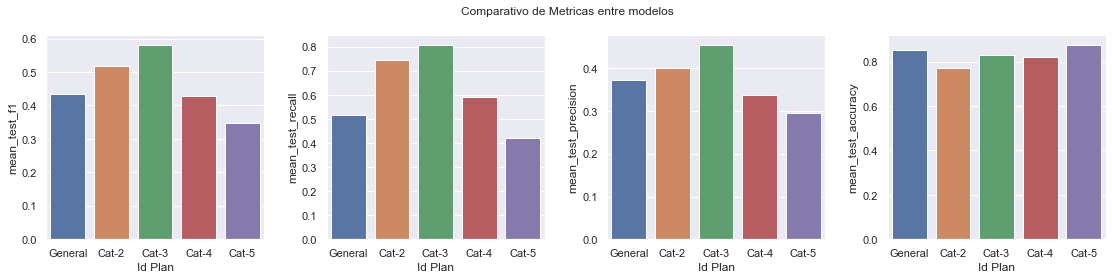

In [77]:
fig, axs = plt.subplots(nrows = 1,ncols =4, figsize=(16,4), squeeze=False)
fig.tight_layout(pad=3)
cols_review = ['mean_test_f1', 'mean_test_recall', 'mean_test_precision','mean_test_accuracy']
#axs.set_title("F1 Promedio comparativo por plan contratado")
for c, e in enumerate(cols_review):
    sns.barplot(x='Product_id',y=e,
                data=full, ax = axs[0][c])
    axs[0][c].set_ylabel(e)
    axs[0][c].set_xlabel("Id Plan")

fig.suptitle('Comparativo de Metricas entre modelos') 
plt.show()   
    

#### comparacíon entre los mejores modelos de cada conjunto.

#### en terminos generales el F1 se logra mejor con modelos individualizados por tipo de producto que el modelo que los considera a todos por igual... sin embargo cabe pensar que el modelo general deberia ser capaz de separar esta situacion si fuera significativa

In [78]:
def chart_producto(dfG,Producto):
    dfG['estimador'] = dfG.param_clf__estimator.apply(lambda x: x.split('(')[0])
    mldf = dfG.melt(id_vars=['rank_test_f1', 'estimador'],value_vars=cols_review).sort_values('rank_test_f1').head(20)
    mldf['eje-x'] = mldf.apply(lambda x: str(x.rank_test_f1) + ' '+ x.estimador , axis=1)
    plt.figure(figsize=(12, 8))

    sns.set(style="darkgrid")
    ax =sns.barplot(x='eje-x',y='value',hue='variable', data=mldf)
    ax.set_ylabel("% alcanzado")
    ax.set_xlabel("Ranking")

    ax.set_title('Comparativo de Metricas entre modelos - '+ Producto) 
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()   

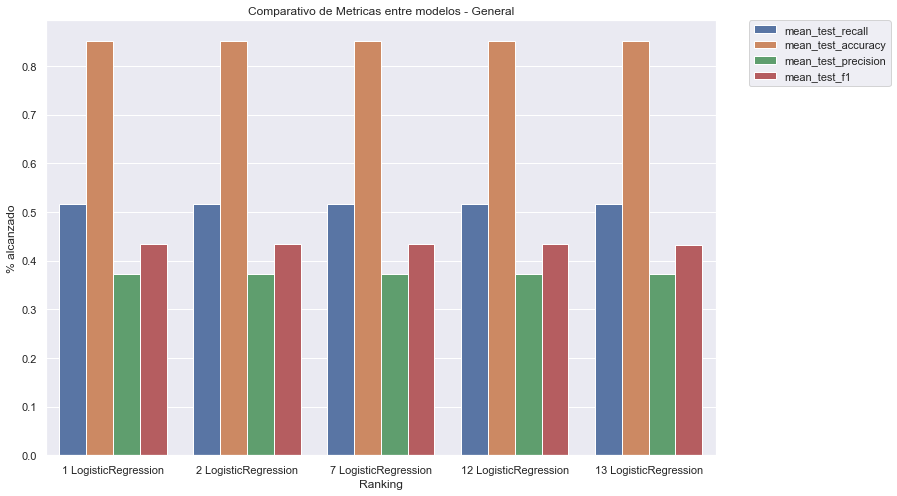

In [79]:
chart_producto(dfG,'General')

#### podemos observar que para el modelo que incluye todos los productos, el estimador mas efectivo es la regresion logistica

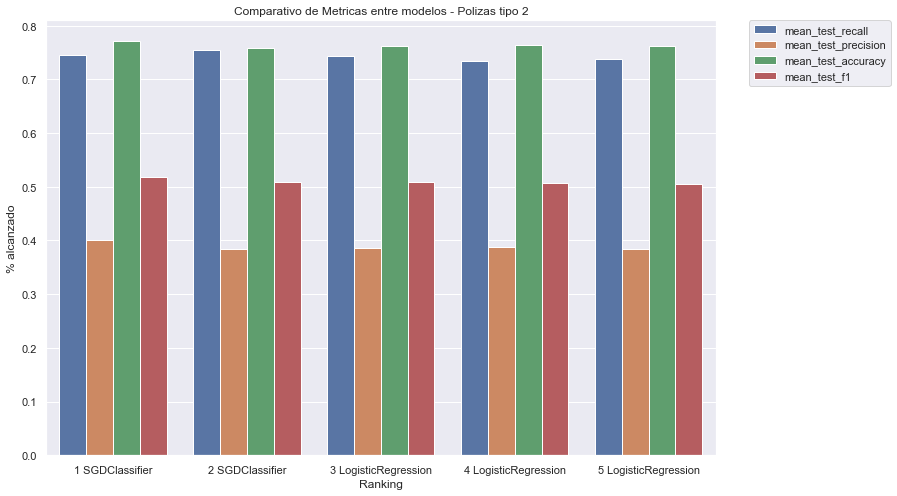

In [80]:
chart_producto(dfp2r,'Polizas tipo 2')

#### Al separar los productos, en el caso del tipo -2, un clasificador SGDC tuvo mejores resultados en F1 que el modelo logistico. 
#### En el caso de la poliza tipo 3 el modelo logistico gana, y en el 4 es nuevamente un SGDC. Poliza Tipo 5 es un modelo logistico.

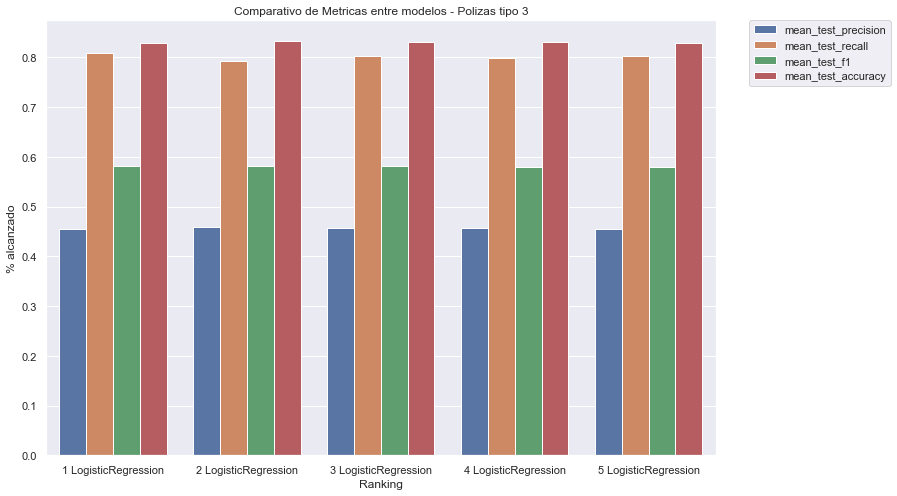

In [81]:
chart_producto(dfp3r,'Polizas tipo 3')

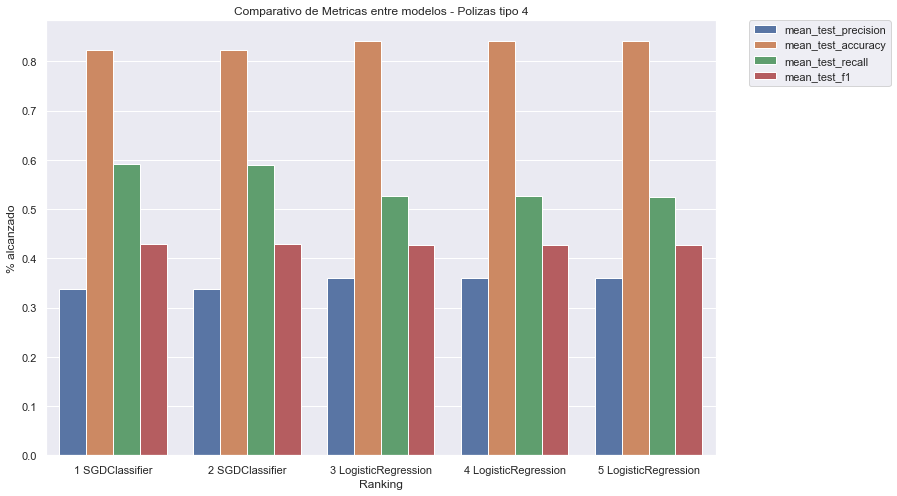

In [82]:
chart_producto(dfp4r,'Polizas tipo 4')

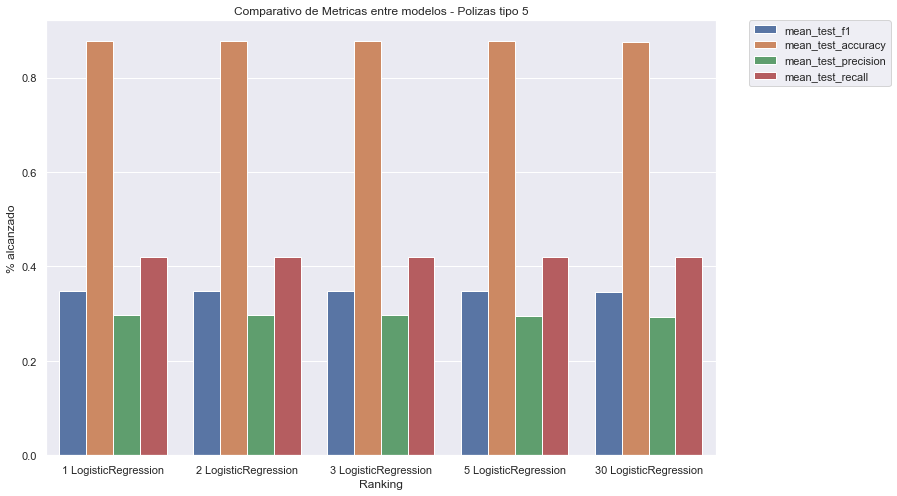

In [83]:
chart_producto(dfp5r,'Polizas tipo 5')


#### Finalmente vamos a comparar los resultados de entrenamiento y test de cada uno de los 5 modelos.

In [84]:

metricas.sufijo[metricas.modelo =='CatBoost'] = 'CatBoost'
metricas.sufijo[metricas.sufijo.isnull()] = 'General'

In [85]:
metricas.head(20)

,sufijo,tipo,modelo,accuracy,f1_score,precision_score,recall_score
0,General,train,SGDClassifier,0.836985,0.433011,0.350823,0.565490
1,General,test,SGDClassifier,0.830898,0.414104,0.334659,0.543011
2,_plan_2,train,SGDClassifier,0.766682,0.516343,0.392934,0.752762
3,_plan_2,test,SGDClassifier,0.771761,0.516691,0.397321,0.738589
4,_plan_3,train,LogisticRegression,0.835836,0.594059,0.466019,0.819113
5,_plan_3,test,LogisticRegression,0.812594,0.542125,0.422857,0.755102
6,_plan_4,train,SGDClassifier,0.818331,0.427121,0.331838,0.599162
7,_plan_4,test,SGDClassifier,0.811707,0.414605,0.319709,0.589615
8,_plan_5,train,LogisticRegression,0.869517,0.347689,0.284238,0.447609
9,_plan_5,test,LogisticRegression,0.869606,0.373576,0.298182,0.500000


In [86]:
#metricas = metricas[metricas.modelo !='CatBoost']

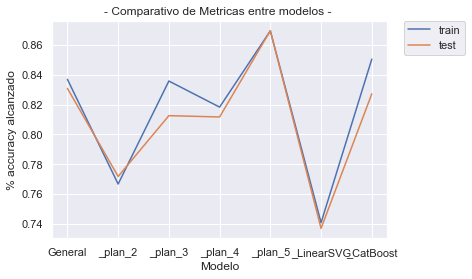

In [87]:
ax =sns.lineplot(x='sufijo',y='accuracy',hue='tipo', data=metricas)
ax.set_ylabel("% accuracy alcanzado")
ax.set_xlabel("Modelo")
ax.set_title('- Comparativo de Metricas entre modelos - ') 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()   

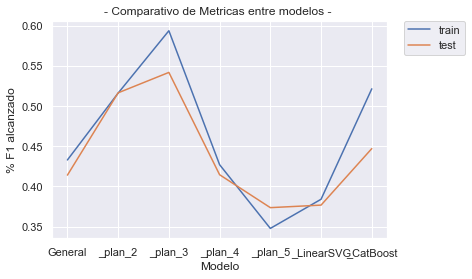

In [88]:
ax =sns.lineplot(x='sufijo',y='f1_score',hue='tipo', data=metricas)
ax.set_ylabel("% F1 alcanzado")
ax.set_xlabel("Modelo")
ax.set_title('- Comparativo de Metricas entre modelos - ') 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()   

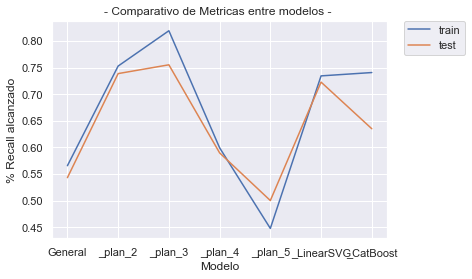

In [89]:
ax =sns.lineplot(x='sufijo',y='recall_score',hue='tipo', data=metricas)
ax.set_ylabel("% Recall alcanzado")
ax.set_xlabel("Modelo")
ax.set_title('- Comparativo de Metricas entre modelos - ') 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()   

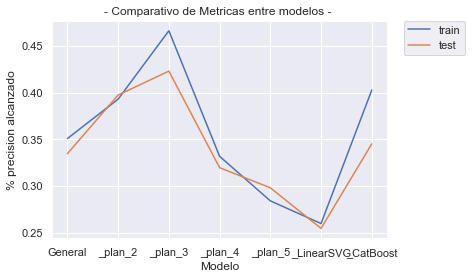

In [90]:
ax =sns.lineplot(x='sufijo',y='precision_score',hue='tipo', data=metricas)
ax.set_ylabel("% precision alcanzado")
ax.set_xlabel("Modelo")
ax.set_title('- Comparativo de Metricas entre modelos - ') 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()   

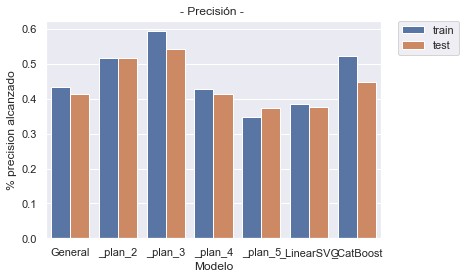

In [91]:

ax =sns.barplot(x='sufijo',y='f1_score',hue='tipo', data=metricas)
ax.set_ylabel("% precision alcanzado")
ax.set_xlabel("Modelo")
ax.set_title('- Precisión - ') 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()   

In [92]:
display(metricas)

,sufijo,tipo,modelo,accuracy,f1_score,precision_score,recall_score
0,General,train,SGDClassifier,0.836985,0.433011,0.350823,0.565490
1,General,test,SGDClassifier,0.830898,0.414104,0.334659,0.543011
2,_plan_2,train,SGDClassifier,0.766682,0.516343,0.392934,0.752762
3,_plan_2,test,SGDClassifier,0.771761,0.516691,0.397321,0.738589
4,_plan_3,train,LogisticRegression,0.835836,0.594059,0.466019,0.819113
5,_plan_3,test,LogisticRegression,0.812594,0.542125,0.422857,0.755102
6,_plan_4,train,SGDClassifier,0.818331,0.427121,0.331838,0.599162
7,_plan_4,test,SGDClassifier,0.811707,0.414605,0.319709,0.589615
8,_plan_5,train,LogisticRegression,0.869517,0.347689,0.284238,0.447609
9,_plan_5,test,LogisticRegression,0.869606,0.373576,0.298182,0.500000


#### Conclusiónes:
    - No pudimos, con los datos disponibles , construir un modelo que pudiera de manera determinante clasificar a quienes no van a completar el proceso.
    - Sin embargo, por la naturaleza del problema, se logra tener un Recall alto, (manejable con umbrales) sin que los falsos positivos lleguen a un nivel en el cual hacer campañas sobre todos los identificados como positivos, lleve a "molestar" a aquellos que igualmente completarian el proceso.
    - Una campaña enfocada sobre los candidatos detectados no tendría un costo tan elevado y podria ayudar en las conversiones.
    
    - Adicionalmente:
        - Parece indicar la naturaleza del problema que cada producto puede ser tratado como un problema separado, con mejores posibilidades de lograr precisión en las predicciones.